# Computer Vision basic

In [ ]:
! pip install tensorflow
! pip install opencv-python

^C


  Using cached flatbuffers-25.12.19-py2.py3-none-any.whl.metadata (1.0 kB)
  Using cached requests-2.34.2-py3-none-any.whl.metadata (4.8 kB)
  Using cached setuptools-84.0.0-py3-none-any.whl.metadata (6.6 kB)
  Using cached charset_normalizer-3.5.1-cp312-cp312-win_amd64.whl.metadata (46 kB)
  Using cached rich-15.0.0-py3-none-any.whl.metadata (18 kB)
  Using cached markdown_it_py-4.2.0-py3-none-any.whl.metadata (7.4 kB)
  Using cached mdurl-0.1.2-py3-none-any.whl.metadata (1.6 kB)
   ---------------------------------------- 0.0/350.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/350.9 MB ? eta -:--:--
   ---------------------------------------- 0.3/350.9 MB ? eta -:--:--
   ---------------------------------------- 1.0/350.9 MB 2.6 MB/s eta 0:02:13
   ---------------------------------------- 1.8/350.9 MB 3.1 MB/s eta 0:01:51
   ---------------------------------------- 2.4/350.9 MB 3.0 MB/s eta 0:01:58
   ---------------------------------------- 3.1/350.9 MB 3.3 MB/s e

In [1]:
import cv2 # do to image
import matplotlib.pyplot as plt # plot
import os

In [ ]:
PATH = os.path.dirname(os.path.dirname(os.getcwd()))
IMAGE_PATH = os.path.join(PATH, r"data\raw\Training & Education Data\CV\test_1.jpg")
img = cv2.imread(IMAGE_PATH)
cv2.imshow("image" , img)
cv2.waitKey(0)
cv2.destroyAllWindows()


In [6]:
if img is None:
    raise FileNotFoundError(f"could not find image at: {IMAGE_PATH}")
else:
    print(f"image found succesfully")
    print(f"image shape: {img.shape}")

image found succesfully
image shape: (451, 680, 3)


In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import datasets, layers , models
import matplotlib.pyplot as plt


In [ ]:
(x_train, y_train),(x_test, y_test) = datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


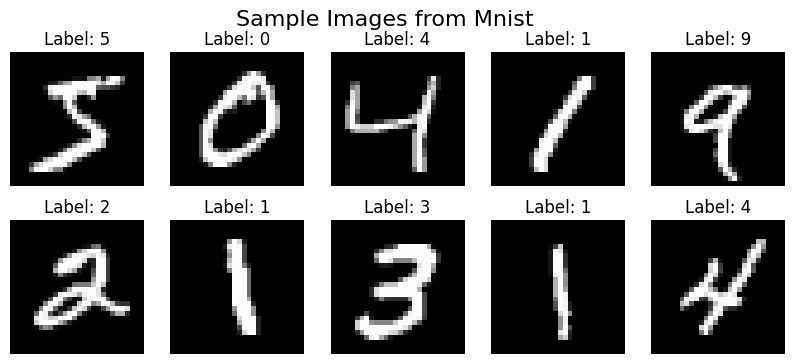

In [ ]:
plt.figure(figsize=(10,4))
for i in range(10):
  plt.subplot(2,5, i + 1)
  plt.imshow(x_train[i], cmap='gray')
  plt.title(f'Label: {y_train[i]}')
  plt.axis('off')
plt.suptitle("Sample Images from Mnist", fontsize=16)
plt.show()


In [ ]:
x_train = x_train /255.0
x_test = x_test / 255.0
x_train = x_train[... , np.newaxis]
x_test = x_test[... , np.newaxis]


In [ ]:
model=models.Sequential([
    layers.Conv2D(32, (3,3) , activation='relu', input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64,(3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')

])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])



In [ ]:
history=model.fit(x_train, y_train, epochs=5 , batch_size=128, validation_data=(x_test, y_test))

Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 50s 102ms/step - accuracy: 0.8423 - loss: 0.5504 - val_accuracy: 0.9795 - val_loss: 0.0674
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 47s 100ms/step - accuracy: 0.9801 - loss: 0.0657 - val_accuracy: 0.9851 - val_loss: 0.0446
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 45s 96ms/step - accuracy: 0.9858 - loss: 0.0458 - val_accuracy: 0.9885 - val_loss: 0.0360
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 83s 97ms/step - accuracy: 0.9893 - loss: 0.0339 - val_accuracy: 0.9867 - val_loss: 0.0371
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 83s 99ms/step - accuracy: 0.9920 - loss: 0.0256 - val_accuracy: 0.9898 - val_loss: 0.0305


In [ ]:
test_loss , test_acc = model.evaluate(x_test , y_test , verbose=1)
print(f"\n Final Test Acc: {test_acc: .4f}")
print(f"\n Final Test Loss: {test_loss: .4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9867 - loss: 0.0380

 Final Test Acc:  0.9898

 Final Test Loss:  0.0305


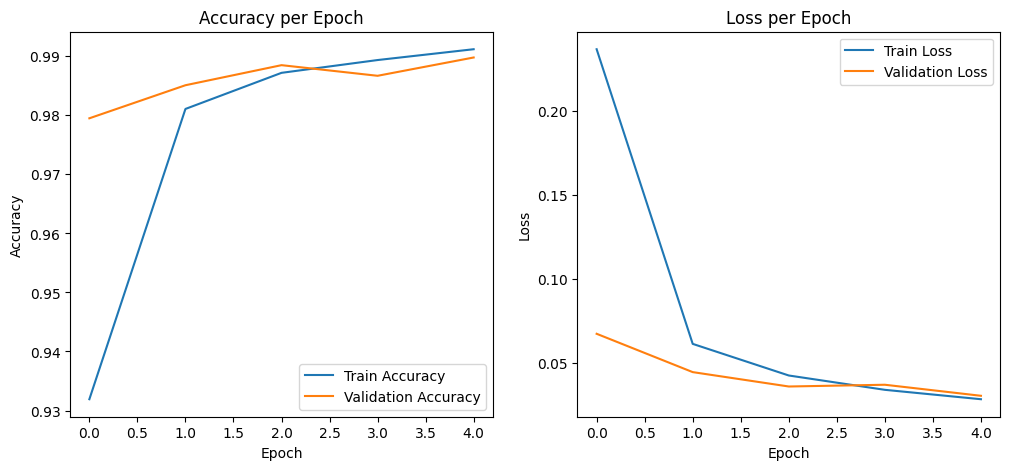

In [ ]:
# Plot training & validation accuracy and loss
plt.figure(figsize=(12, 5))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy per Epoch')
plt.legend()

# Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss per Epoch')
plt.legend()

plt.show()


In [ ]:
predictions=model.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step


In [ ]:
predictions[1]

array([4.7401194e-05, 2.2343085e-05, 9.9982190e-01, 1.0763693e-09,
       9.4827246e-10, 7.4029331e-11, 1.0698438e-04, 2.2635127e-09,
       1.4689575e-06, 5.1737268e-09], dtype=float32)

In [ ]:
y_pred = np.argmax(predictions, axis=1)

In [ ]:
i= 8
print("Predicted Probabilities" , predictions[i])
print("Predicted Class:" , np.argmax(predictions[i]))
print("True Class:" , y_test[i])


Predicted Probabilities [1.1301048e-06 3.7451396e-12 3.1324781e-08 9.5492692e-10 2.8909761e-07
 9.8981917e-01 9.7735114e-03 4.2860020e-08 1.2778098e-04 2.7813425e-04]
Predicted Class: 5
True Class: 5


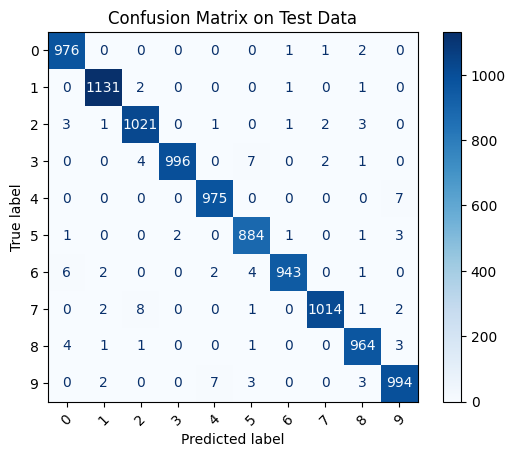

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title("Confusion Matrix on Test Data")
plt.show()


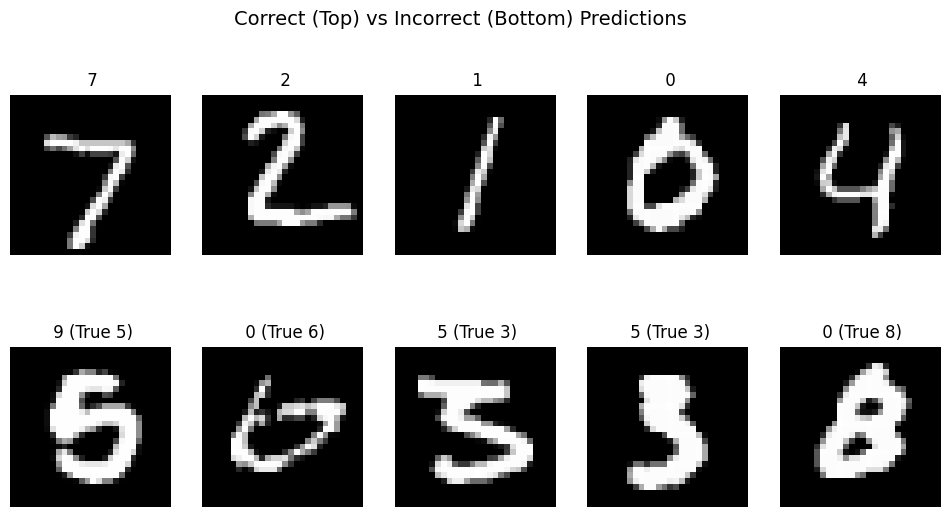

In [ ]:

correct_idx = np.where(y_pred == y_test)[0]
incorrect_idx = np.where(y_pred != y_test)[0]

plt.figure(figsize=(12, 6))

for i, idx in enumerate(correct_idx[:5]):
    plt.subplot(2, 5, i+1)
    plt.imshow(x_test[idx].squeeze(), cmap='gray')
    plt.title(f" {y_pred[idx]}")
    plt.axis('off')

for i, idx in enumerate(incorrect_idx[:5]):
    plt.subplot(2, 5, i+6)
    plt.imshow(x_test[idx].squeeze(), cmap='gray')
    plt.title(f" {y_pred[idx]} (True {y_test[idx]})")
    plt.axis('off')

plt.suptitle("Correct (Top) vs Incorrect (Bottom) Predictions", fontsize=14)
plt.show()


In [ ]:
x_train_new , x_val , y_train_new, y_val=train_test_split(x_train,y_train, test_size=0.2, random_state=42, stratify=y_train)

In [ ]:
print("training set:" , x_train_new.shape)
print("validation set:", x_val.shape)
print("test set:" , x_test.shape)

training set: (48000, 28, 28)
validation set: (12000, 28, 28)
test set: (10000, 28, 28)


In [ ]:
history=model.fit(x_train_new, y_train_new,epochs=5, validation_data=(x_val,y_val))